In [123]:
import matplotlib.pyplot as plt
import pandas as pd
import math, numpy as np
import re
import seaborn as sns

In [124]:
time_cache = '../data/outs/03282/all_time_cache.csv'
ops = '../data/outs/03282/all_ops.csv'

try:
    df_tcache = pd.read_csv(time_cache, sep=' ')
    df_ops = pd.read_csv(ops, sep=' ')
    print("Dados lidos com sucesso!")

except FileNotFoundError:
    print(f"Erro: Arquivo não encontrado!")

Dados lidos com sucesso!


In [125]:
df_tcache.dtypes

nome           object
n               int64
m               int64
c               int64
insert          int64
extractMin      int64
dk              int64
bkmp            int64
upd             int64
fila           object
cpu_time        int64
wall_time       int64
l1_ac           int64
l1_miss         int64
llc_ac          int64
llc_miss        int64
cycles          int64
inst            int64
dtlb            int64
page_faults     int64
branch_inst     int64
branch_miss     int64
dtype: object

In [126]:
# selecionar todos que não são MEM

df_tcache = df_tcache[~df_tcache["nome"].str.startswith("MEM")]

## Tabela Geral dos EUA

In [127]:
df_usa = df_tcache[df_tcache["nome"] == "USA"]
df_usa.head()

,nome,n,m,c,insert,extractMin,dk,bkmp,upd,fila,...,l1_ac,l1_miss,llc_ac,llc_miss,cycles,inst,dtlb,page_faults,branch_inst,branch_miss
1540,USA,23947347,58333344,368855,25658103,25658103,0,19842029,0,1LVBQ,...,12787103266,331033486,85272112,27085982,16104631803,26486860617,20950363,2120,4919987381,48283478
1541,USA,23947347,58333344,368855,25669398,25669398,0,16298923,0,1LVBQ,...,12737847312,339762806,91959781,26968733,16150728069,26442930051,23385635,1576,4924301230,45311553
1542,USA,23947347,58333344,368855,25666226,25666226,0,27651252,0,1LVBQ,...,12907686738,310710693,73545951,24990954,15633756273,26675861443,15748536,0,4927458296,49598626
1543,USA,23947347,58333344,368855,25666263,25666263,0,13800677,0,1LVBQ,...,12696552174,333350458,88841430,26715327,16008030157,26350440300,22004674,35,4912759481,45917231
1544,USA,23947347,58333344,368855,25663252,25663252,0,29010095,0,1LVBQ,...,12938042749,315076985,76319438,25822559,15788362162,26720771343,16680898,0,4940596369,49030563


In [128]:
df_usa = df_usa.groupby("fila").mean(numeric_only=True)
df_usa

,n,m,c,insert,extractMin,dk,bkmp,upd,cpu_time,wall_time,l1_ac,l1_miss,llc_ac,llc_miss,cycles,inst,dtlb,page_faults,branch_inst,branch_miss
fila,,,,,,,,,,,,,,,,,,,,
1LVBQ,23947347.0,58333344.0,368855.0,25665024.5,25665024.5,0.0,23756000.8,0.0,6691.2,6693.2,1.285382e+10,323261908.0,81280688.2,25942047.6,1.586745e+10,2.660086e+10,18974868.6,377.5,4.929955e+09,47884366.3
1LVBQDK,23947347.0,58333344.0,368855.0,25666427.1,23947347.0,1719080.1,25623474.7,0.0,5872.7,5874.4,1.130554e+10,372422381.2,78255103.9,21387733.7,1.402119e+10,2.214698e+10,20396099.8,7.0,3.547530e+09,58416015.2
2LVBQ,23947347.0,58333344.0,368855.0,25665824.5,25665824.5,0.0,45166552.4,44310.9,6727.1,6728.8,1.733084e+10,280940055.4,52535799.5,16709895.9,1.584148e+10,3.546867e+10,13106723.8,2.2,6.693786e+09,49454538.1
2LVBQDK,23947347.0,58333344.0,368855.0,25666337.6,23947347.0,1718990.6,41691391.9,40945.1,6351.3,6352.8,1.399949e+10,405791750.2,72061141.4,19687487.1,1.507434e+10,2.675402e+10,20247309.5,5.4,3.947219e+09,59295821.5
3LVBQ,23947347.0,58333344.0,368855.0,31054061.7,31054061.7,0.0,4278974.9,34524.9,7878.9,7881.3,2.248240e+10,262230648.7,56820741.8,17062059.0,1.837740e+10,4.544714e+10,14161978.5,8.2,7.869143e+09,47709613.1
3LVBQDK,23947347.0,58333344.0,368855.0,31051494.7,27976086.3,3075408.4,4282000.4,34558.7,7281.8,7282.8,1.856634e+10,411481585.4,73915733.6,20140261.8,1.668017e+10,3.522102e+10,20028965.1,0.2,4.791497e+09,54095211.4
4LVBQ,23947347.0,58333344.0,368855.0,35986552.0,35986552.0,0.0,1938708.6,63805.5,9058.0,9059.8,2.679746e+10,286503134.5,63367550.0,18203010.3,2.106681e+10,5.398108e+10,15656315.9,5.9,9.248162e+09,51550412.1
4LVBQDK,23947347.0,58333344.0,368855.0,35970470.8,32197647.1,3772823.7,2188499.6,72777.1,8162.0,8164.3,2.216394e+10,455777873.6,80704155.0,20599747.8,1.854402e+10,4.178586e+10,21053644.1,5.5,5.625572e+09,56175053.5
5LVBQ,23947347.0,58333344.0,368855.0,26672875.9,26672875.9,0.0,3621642.3,218566.0,7912.7,7915.0,2.325256e+10,228653274.6,53923197.9,17008360.7,1.844934e+10,4.686923e+10,13393346.2,7.3,7.869662e+09,43359838.2


In [129]:
df_usa = df_usa.copy()
df_usa.head()

df_usa["ipc"] = df_usa["inst"] / df_usa["cycles"]

colunas = [
    "cpu_time", "wall_time", "l1_ac", "l1_miss",
    "llc_ac", "llc_miss", "branch_inst", "branch_miss", "inst", "bkmp"
]

df_usa = df_usa[colunas]

In [130]:
mins = df_usa.min()

mins["bkmp"] = df_usa.loc[df_usa["bkmp"] != 0, "bkmp"].min()

mins
df_norm = df_usa / mins

In [131]:
# num = df_usa.select_dtypes(include="number").copy()
# df_norm = num / num.min()

In [132]:
df_norm.style.highlight_min(axis=0, color="lightgreen").highlight_max(axis=0, color="salmon")

,cpu_time,wall_time,l1_ac,l1_miss,llc_ac,llc_miss,branch_inst,branch_miss,inst,bkmp
fila,,,,,,,,,,
1LVBQ,1.139374,1.139384,1.136950,1.430268,1.547149,1.552496,1.389687,1.104348,1.201105,12.253518
1LVBQDK,1.000000,1.000000,1.000000,1.647778,1.489558,1.279944,1.000000,1.347238,1.000000,13.216775
2LVBQ,1.145487,1.145445,1.532952,1.243016,1.000000,1.000000,1.886886,1.140561,1.601513,23.297236
2LVBQDK,1.081496,1.081438,1.238286,1.795420,1.371658,1.178193,1.112667,1.367529,1.208021,21.504723
3LVBQ,1.341615,1.341635,1.988618,1.160236,1.081562,1.021075,2.218203,1.100318,2.052069,2.207126
3LVBQDK,1.239941,1.239752,1.642234,1.820595,1.406959,1.205289,1.350657,1.247588,1.590331,2.208687
4LVBQ,1.542391,1.542251,2.370296,1.267629,1.206178,1.089355,2.606930,1.188898,2.437401,1.000000
4LVBQDK,1.389821,1.389810,1.960450,2.016583,1.536174,1.232787,1.585772,1.295555,1.886752,1.128844
5LVBQ,1.347370,1.347372,2.056742,1.011673,1.026409,1.017862,2.218350,1.000000,2.116281,1.868069


In [133]:
latex = df_norm.to_latex(
    index=True,
    float_format="%.2f",
    longtable=False,
    escape=False
)

print(latex)

\begin{tabular}{lrrrrrrrrrr}
\toprule
 & cpu_time & wall_time & l1_ac & l1_miss & llc_ac & llc_miss & branch_inst & branch_miss & inst & bkmp \\
fila &  &  &  &  &  &  &  &  &  &  \\
\midrule
1LVBQ & 1.14 & 1.14 & 1.14 & 1.43 & 1.55 & 1.55 & 1.39 & 1.10 & 1.20 & 12.25 \\
1LVBQDK & 1.00 & 1.00 & 1.00 & 1.65 & 1.49 & 1.28 & 1.00 & 1.35 & 1.00 & 13.22 \\
2LVBQ & 1.15 & 1.15 & 1.53 & 1.24 & 1.00 & 1.00 & 1.89 & 1.14 & 1.60 & 23.30 \\
2LVBQDK & 1.08 & 1.08 & 1.24 & 1.80 & 1.37 & 1.18 & 1.11 & 1.37 & 1.21 & 21.50 \\
3LVBQ & 1.34 & 1.34 & 1.99 & 1.16 & 1.08 & 1.02 & 2.22 & 1.10 & 2.05 & 2.21 \\
3LVBQDK & 1.24 & 1.24 & 1.64 & 1.82 & 1.41 & 1.21 & 1.35 & 1.25 & 1.59 & 2.21 \\
4LVBQ & 1.54 & 1.54 & 2.37 & 1.27 & 1.21 & 1.09 & 2.61 & 1.19 & 2.44 & 1.00 \\
4LVBQDK & 1.39 & 1.39 & 1.96 & 2.02 & 1.54 & 1.23 & 1.59 & 1.30 & 1.89 & 1.13 \\
5LVBQ & 1.35 & 1.35 & 2.06 & 1.01 & 1.03 & 1.02 & 2.22 & 1.00 & 2.12 & 1.87 \\
5LVBQDK & 1.24 & 1.24 & 1.71 & 1.77 & 1.33 & 1.21 & 1.26 & 1.16 & 1.63 & 2.01 \\
6LVB

# Tempo de execução

In [134]:
df_tcache.head()

,nome,n,m,c,insert,extractMin,dk,bkmp,upd,fila,...,l1_ac,l1_miss,llc_ac,llc_miss,cycles,inst,dtlb,page_faults,branch_inst,branch_miss
0,NY,264346,733846,36946,298624,298624,0,917980,0,1LVBQ,...,185354637,2774630,283093,110406,163358372,395355457,12837,0,72416854,724807
1,NY,264346,733846,36946,298741,298741,0,831499,0,1LVBQ,...,183699306,2784631,288094,116396,157962417,391112107,12709,0,72134789,728535
2,NY,264346,733846,36946,298820,298820,0,790126,0,1LVBQ,...,183380594,2811272,279887,111570,154010031,383629380,11767,0,71667381,721787
3,NY,264346,733846,36946,298815,298815,0,1008314,0,1LVBQ,...,186763024,2765345,313321,132390,166166459,403283591,12054,0,72796542,734600
4,NY,264346,733846,36946,298923,298923,0,702910,0,1LVBQ,...,183920888,2735102,292603,117253,161668777,391960132,13115,0,72260137,740833


### Perguntas

#### Gerais
- Em média, quanto extractMin a mais são realizados em filas sem DK? (incluir DK)
- Quem realiza mais/menos instruções por instância?
- Quem tem mais cache miss (total e rate) por instância?
- Quem tem mais branch miss (total e rate) por instância?
- Dtlb e page faults tem alguma relevância?

#### Buckets
- Quantos buckets vazios cada estrutura avalia?
- Quantas operações de expansão são realizadas?
- Quantos updates cada estrutura realiza?
- Qual bucket tem mais/menos branch miss (total e rate) por instância?
- Quel bucket tem mais/menos cache miss (total e rate) por instância?


In [135]:
df_time = df_tcache[
    ['nome', 'n', 'c', 'fila', 'cpu_time', 'wall_time']
].copy()
df_time

,nome,n,c,fila,cpu_time,wall_time
0,NY,264346,36946,1LVBQ,65,65
1,NY,264346,36946,1LVBQ,65,65
2,NY,264346,36946,1LVBQ,64,64
3,NY,264346,36946,1LVBQ,66,66
4,NY,264346,36946,1LVBQ,66,66
...,...,...,...,...,...,...
1675,USA,23947347,368855,FIBH,19653,19660
1676,USA,23947347,368855,FIBH,18831,18834
1677,USA,23947347,368855,FIBH,19464,19467
1678,USA,23947347,368855,FIBH,17894,17897


In [136]:
df_time["wall_cpu_ratio"] = df_time["wall_time"] / df_time["cpu_time"]
print("Min ratio", df_time["wall_cpu_ratio"].min())
print("Max ratio", df_time["wall_cpu_ratio"].max())

Min ratio 1.0
Max ratio 1.0113636363636365


Logo, CPU Bound

In [137]:
df_cpu = df_tcache[
    ['nome', 'n', 'c', 'fila', 'cpu_time']
].copy()
df_cpu = (
    df_cpu.groupby(['nome', 'fila'], as_index=False)
      .agg(
           cpu_mean=('cpu_time', 'mean'),
           cpu_std =('cpu_time', 'std'),
           cpu_var =('cpu_time', 'var'),
           n=('n', 'first'),
      )
)
df_cpu['cpu_cv'] = df_cpu['cpu_std'] / df_cpu['cpu_mean']
df_cpu

,nome,fila,cpu_mean,cpu_std,cpu_var,n,cpu_cv
0,BAY,1LVBQ,84.1,1.286684,1.655556,321270,0.015299
1,BAY,1LVBQDK,59.0,0.666667,0.444444,321270,0.011299
2,BAY,2LVBQ,95.1,2.424413,5.877778,321270,0.025493
3,BAY,2LVBQDK,66.3,0.948683,0.900000,321270,0.014309
4,BAY,3LVBQ,84.7,0.948683,0.900000,321270,0.011201
...,...,...,...,...,...,...,...
163,W,5LVBQDK,1773.6,34.461573,1187.600000,6262104,0.019430
164,W,6LVBQ,1999.1,34.520364,1191.655556,6262104,0.017268
165,W,6LVBQDK,1812.4,44.395195,1970.933333,6262104,0.024495
166,W,BINH,2683.0,71.748016,5147.777778,6262104,0.026742


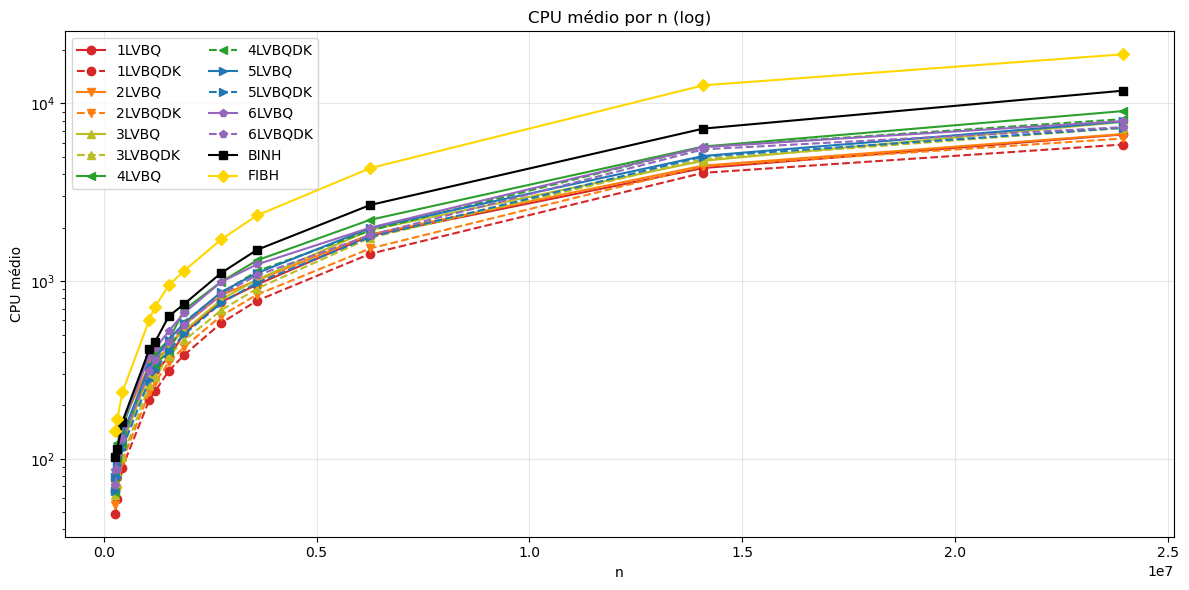

In [138]:

# selecionar BINH, Fibonacci e todas LVBQ (1–6) com ou sem DK
mask = (
    (df_cpu["fila"] == "BINH") |
    (df_cpu["fila"] == "FIBH") |  # adiciona Fibonacci
    (df_cpu["fila"].str.match(r"[1-6]LVBQ(DK)?"))
)

df_sel = df_cpu[mask].copy()

# ordenar por n (ESSENCIAL para gráfico de linhas)
df_sel = df_sel.sort_values("n")

# ordem consistente das curvas
filas_sel = sorted(df_sel["fila"].unique())

# 🔹 marcadores por nível LVBQ
marcadores_nivel = {
    1: "o",   # círculo
    2: "v",   # triângulo para baixo
    3: "^",   # triângulo para cima
    4: "<",   # triângulo para esquerda
    5: ">",   # triângulo para direita
    6: "p",   # pentágono
}

plt.figure(figsize=(12, 6))

for fila in filas_sel:
    dados = df_sel[df_sel["fila"] == fila]

    if dados.empty:
        continue

    # ===== BINH =====
    if fila == "BINH":
        color = "black"
        linestyle = "-"
        marker = "s"

    # ===== FIBH (Fibonacci) =====
    elif fila == "FIBH":
        color = "gold"
        linestyle = "-"
        marker = "D"  # diamante

    # ===== LVBQ / LVBQDK =====
    else:
        nivel = int(re.match(r"\d+", fila).group())

        # 🎨 cor por nível (1–6)
        cores = {
            1: "tab:red",
            2: "tab:orange",
            3: "tab:olive",
            4: "tab:green",
            5: "tab:blue",
            6: "tab:purple",
        }
        color = cores[nivel]

        # DK → tracejado
        linestyle = "--" if "DK" in fila else "-"

        # marcador por nível
        marker = marcadores_nivel[nivel]

    plt.plot(
        dados["n"],
        dados["cpu_mean"],
        label=fila,
        color=color,
        linestyle=linestyle,
        marker=marker
    )

plt.xlabel("n")
plt.ylabel("CPU médio")
plt.title("CPU médio por n (log)")
plt.yscale("log")
plt.legend(ncol=2)  # legenda mais compacta
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

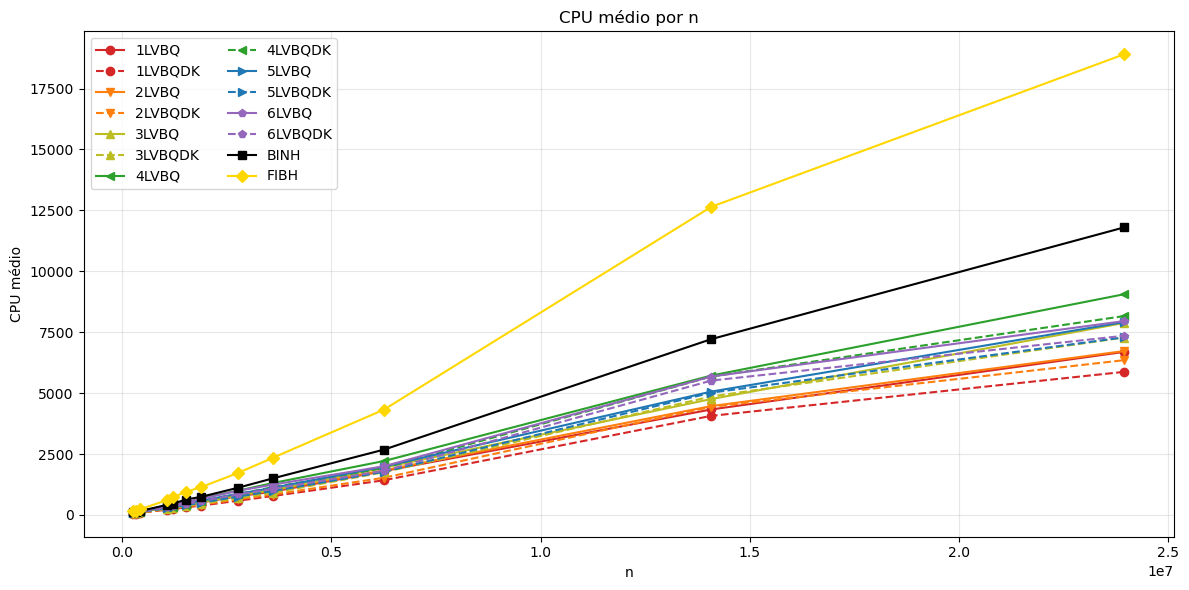

In [139]:

# selecionar BINH, Fibonacci e todas LVBQ (1–6) com ou sem DK
mask = (
    (df_cpu["fila"] == "BINH") |
    (df_cpu["fila"] == "FIBH") |  # adiciona Fibonacci
    (df_cpu["fila"].str.match(r"[1-6]LVBQ(DK)?"))
)

df_sel = df_cpu[mask].copy()

# ordenar por n (ESSENCIAL para gráfico de linhas)
df_sel = df_sel.sort_values("n")

# ordem consistente das curvas
filas_sel = sorted(df_sel["fila"].unique())

# 🔹 marcadores por nível LVBQ
marcadores_nivel = {
    1: "o",   # círculo
    2: "v",   # triângulo para baixo
    3: "^",   # triângulo para cima
    4: "<",   # triângulo para esquerda
    5: ">",   # triângulo para direita
    6: "p",   # pentágono
}

plt.figure(figsize=(12, 6))

for fila in filas_sel:
    dados = df_sel[df_sel["fila"] == fila]

    if dados.empty:
        continue

    # ===== BINH =====
    if fila == "BINH":
        color = "black"
        linestyle = "-"
        marker = "s"

    # ===== FIBH (Fibonacci) =====
    elif fila == "FIBH":
        color = "gold"
        linestyle = "-"
        marker = "D"  # diamante

    # ===== LVBQ / LVBQDK =====
    else:
        nivel = int(re.match(r"\d+", fila).group())

        # 🎨 cor por nível (1–6)
        cores = {
            1: "tab:red",
            2: "tab:orange",
            3: "tab:olive",
            4: "tab:green",
            5: "tab:blue",
            6: "tab:purple",
        }
        color = cores[nivel]

        # DK → tracejado
        linestyle = "--" if "DK" in fila else "-"

        # marcador por nível
        marker = marcadores_nivel[nivel]

    plt.plot(
        dados["n"],
        dados["cpu_mean"],
        label=fila,
        color=color,
        linestyle=linestyle,
        marker=marker
    )

plt.xlabel("n")
plt.ylabel("CPU médio")
plt.title("CPU médio por n")
plt.legend(ncol=2)  # legenda mais compacta
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [140]:
import re

# garantir ordem
df_sel = df_sel.sort_values(["fila", "n"])

for fila in filas_sel:
    dados = df_sel[df_sel["fila"] == fila]

    if dados.empty:
        continue

    print(f"% --- {fila} ---")
    print(r"\addplot[color=blue, mark=o]")
    print("coordinates {")

    for _, row in dados.iterrows():
        x = int(row["n"])
        y = float(row["cpu_mean"])
        print(f"  ({x},{y:.1f})")

    print("};")

    # legenda com nome da fila
    print(rf"\addlegendentry{{\textit{{Heap}} {fila}}}")
    print()

% --- 1LVBQ ---
\addplot[color=blue, mark=o]
coordinates {
  (264346,65.8)
  (321270,84.1)
  (435666,134.1)
  (1070376,298.3)
  (1207945,313.9)
  (1524453,369.1)
  (1890815,511.7)
  (2758119,763.3)
  (3598623,955.4)
  (6262104,1803.6)
  (14081816,4329.7)
  (23947347,6691.2)
};
\addlegendentry{\textit{Heap} 1LVBQ}

% --- 1LVBQDK ---
\addplot[color=blue, mark=o]
coordinates {
  (264346,49.0)
  (321270,59.0)
  (435666,89.2)
  (1070376,215.1)
  (1207945,240.0)
  (1524453,312.0)
  (1890815,384.1)
  (2758119,580.8)
  (3598623,775.2)
  (6262104,1425.3)
  (14081816,4067.0)
  (23947347,5872.7)
};
\addlegendentry{\textit{Heap} 1LVBQDK}

% --- 2LVBQ ---
\addplot[color=blue, mark=o]
coordinates {
  (264346,70.9)
  (321270,95.1)
  (435666,158.8)
  (1070376,336.2)
  (1207945,368.5)
  (1524453,412.3)
  (1890815,566.8)
  (2758119,832.5)
  (3598623,1009.7)
  (6262104,1832.7)
  (14081816,4467.0)
  (23947347,6727.1)
};
\addlegendentry{\textit{Heap} 2LVBQ}

% --- 2LVBQDK ---
\addplot[color=blue, mark=o]
c

## Operações

In [141]:
df_usa = df_tcache[df_tcache["nome"] == "USA"]
df_usa = df_usa.groupby("fila").mean(numeric_only=True)
df_usa

,n,m,c,insert,extractMin,dk,bkmp,upd,cpu_time,wall_time,l1_ac,l1_miss,llc_ac,llc_miss,cycles,inst,dtlb,page_faults,branch_inst,branch_miss
fila,,,,,,,,,,,,,,,,,,,,
1LVBQ,23947347.0,58333344.0,368855.0,25665024.5,25665024.5,0.0,23756000.8,0.0,6691.2,6693.2,1.285382e+10,323261908.0,81280688.2,25942047.6,1.586745e+10,2.660086e+10,18974868.6,377.5,4.929955e+09,47884366.3
1LVBQDK,23947347.0,58333344.0,368855.0,25666427.1,23947347.0,1719080.1,25623474.7,0.0,5872.7,5874.4,1.130554e+10,372422381.2,78255103.9,21387733.7,1.402119e+10,2.214698e+10,20396099.8,7.0,3.547530e+09,58416015.2
2LVBQ,23947347.0,58333344.0,368855.0,25665824.5,25665824.5,0.0,45166552.4,44310.9,6727.1,6728.8,1.733084e+10,280940055.4,52535799.5,16709895.9,1.584148e+10,3.546867e+10,13106723.8,2.2,6.693786e+09,49454538.1
2LVBQDK,23947347.0,58333344.0,368855.0,25666337.6,23947347.0,1718990.6,41691391.9,40945.1,6351.3,6352.8,1.399949e+10,405791750.2,72061141.4,19687487.1,1.507434e+10,2.675402e+10,20247309.5,5.4,3.947219e+09,59295821.5
3LVBQ,23947347.0,58333344.0,368855.0,31054061.7,31054061.7,0.0,4278974.9,34524.9,7878.9,7881.3,2.248240e+10,262230648.7,56820741.8,17062059.0,1.837740e+10,4.544714e+10,14161978.5,8.2,7.869143e+09,47709613.1
3LVBQDK,23947347.0,58333344.0,368855.0,31051494.7,27976086.3,3075408.4,4282000.4,34558.7,7281.8,7282.8,1.856634e+10,411481585.4,73915733.6,20140261.8,1.668017e+10,3.522102e+10,20028965.1,0.2,4.791497e+09,54095211.4
4LVBQ,23947347.0,58333344.0,368855.0,35986552.0,35986552.0,0.0,1938708.6,63805.5,9058.0,9059.8,2.679746e+10,286503134.5,63367550.0,18203010.3,2.106681e+10,5.398108e+10,15656315.9,5.9,9.248162e+09,51550412.1
4LVBQDK,23947347.0,58333344.0,368855.0,35970470.8,32197647.1,3772823.7,2188499.6,72777.1,8162.0,8164.3,2.216394e+10,455777873.6,80704155.0,20599747.8,1.854402e+10,4.178586e+10,21053644.1,5.5,5.625572e+09,56175053.5
5LVBQ,23947347.0,58333344.0,368855.0,26672875.9,26672875.9,0.0,3621642.3,218566.0,7912.7,7915.0,2.325256e+10,228653274.6,53923197.9,17008360.7,1.844934e+10,4.686923e+10,13393346.2,7.3,7.869662e+09,43359838.2


In [142]:
df_ops = df_usa.copy()
df_ops["extractMin_extra"] = df_ops["extractMin"]-df_ops["n"]

In [143]:
colunas = [
    "n", "c", "insert", "extractMin", "dk", "bkmp",
    "upd", "extractMin_extra"
]
df_ops = df_ops[colunas]
df_ops

,n,c,insert,extractMin,dk,bkmp,upd,extractMin_extra
fila,,,,,,,,
1LVBQ,23947347.0,368855.0,25665024.5,25665024.5,0.0,23756000.8,0.0,1717677.5
1LVBQDK,23947347.0,368855.0,25666427.1,23947347.0,1719080.1,25623474.7,0.0,0.0
2LVBQ,23947347.0,368855.0,25665824.5,25665824.5,0.0,45166552.4,44310.9,1718477.5
2LVBQDK,23947347.0,368855.0,25666337.6,23947347.0,1718990.6,41691391.9,40945.1,0.0
3LVBQ,23947347.0,368855.0,31054061.7,31054061.7,0.0,4278974.9,34524.9,7106714.7
3LVBQDK,23947347.0,368855.0,31051494.7,27976086.3,3075408.4,4282000.4,34558.7,4028739.3
4LVBQ,23947347.0,368855.0,35986552.0,35986552.0,0.0,1938708.6,63805.5,12039205.0
4LVBQDK,23947347.0,368855.0,35970470.8,32197647.1,3772823.7,2188499.6,72777.1,8250300.1
5LVBQ,23947347.0,368855.0,26672875.9,26672875.9,0.0,3621642.3,218566.0,2725528.9


In [144]:
df_ops["extractMin_extra_pct"] = 100 * df_ops["extractMin_extra"] / df_ops["n"]
df_line = df_ops["extractMin_extra_pct"].to_frame().T
df_line

fila,1LVBQ,1LVBQDK,2LVBQ,2LVBQDK,3LVBQ,3LVBQDK,4LVBQ,4LVBQDK,5LVBQ,5LVBQDK,6LVBQ,6LVBQDK,BINH,FIBH
extractMin_extra_pct,7.172726,0.0,7.176066,0.0,29.676418,16.823322,50.273648,34.451833,11.38134,2.568043,11.381469,2.573496,7.180704,0.0


# Instrucoes por op de fila

In [145]:
df_ops = pd.read_csv(ops, sep=' ')

In [146]:
colunas = [
    "nome", "fila", "n", "c", "cycles", "inst", "operacao"
]
df_ops = df_ops[colunas]
df_ops = df_ops[(df_ops["cycles"] > 0) & (df_ops["inst"] > 0)]
df_ops.head()

,nome,fila,n,c,cycles,inst,operacao
60,PIN2,1LVBQ,100,499,3727,2164,insert
61,PIN2,1LVBQ,100,499,3193,1135,extractMin
62,PIN2,1LVBQ,100,499,3684,1891,insert
63,PIN2,1LVBQ,100,499,3222,1087,insert
64,PIN2,1LVBQ,100,499,3412,1225,extractMin


In [147]:
df_agg = df_ops.groupby(
    ["fila", "n", "c", "operacao"],
    as_index=False
).sum(numeric_only=True)
df_agg

,fila,n,c,operacao,cycles,inst
0,1LVBQ,100,499,extractMin,416177,167921
1,1LVBQ,100,499,insert,311788,173064
2,1LVBQ,1000,4999,extractMin,3074395,1368853
3,1LVBQ,1000,4999,insert,3570902,2028440
4,1LVBQ,10000,50000,extractMin,36193603,15935302
...,...,...,...,...,...,...
105,FIBH,1000,4999,extractMin,3106515,2067443
106,FIBH,10000,50000,dk,31672930,10295167
107,FIBH,10000,50000,extractMin,37478144,28924620
108,FIBH,100000,499999,dk,400506935,102128904


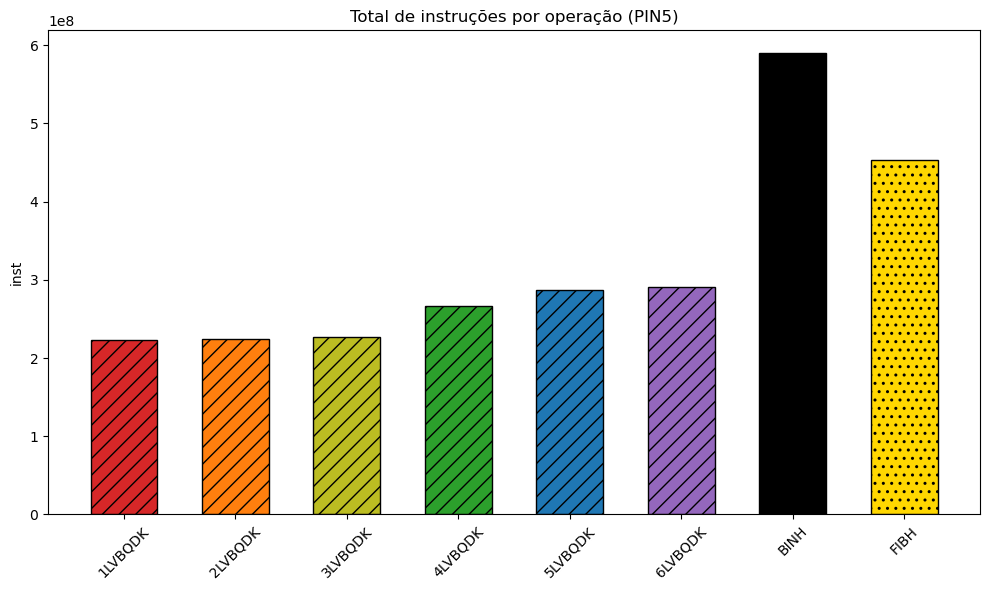

In [148]:
import re
import numpy as np
import matplotlib.pyplot as plt

# --- filtrar ---
df = df_ops.copy()

df = df[
    (df["nome"] == "PIN5") &
    (
        df["fila"].str.endswith("DK") |
        df["fila"].isin(["BINH", "FIBH"])
    )
]

# --- agregar (agora sem n!) ---
df_agg = df.groupby("fila", as_index=False).sum(numeric_only=True)

# --- eixos ---
filas = sorted(df_agg["fila"].unique())
x = np.arange(len(filas))

# --- cores ---
colors = {
    "1": "tab:red",
    "2": "tab:orange",
    "3": "tab:olive",
    "4": "tab:green",
    "5": "tab:blue",
    "6": "tab:purple",
}

plt.figure(figsize=(10, 6))

for i, fila in enumerate(filas):

    val = df_agg[df_agg["fila"] == fila]["inst"].values[0]

    # ===== especiais =====
    if fila == "BINH":
        color = "black"
        hatch = "xx"
    elif fila == "FIBH":
        color = "gold"
        hatch = ".."

    # ===== DK =====
    else:
        m = re.match(r"\d+", fila)
        nivel = m.group() if m else None

        color = colors.get(nivel, "tab:gray")
        hatch = "//"

    plt.bar(
        x[i],
        val,
        width=0.6,
        label=fila,
        color=color,
        hatch=hatch,
        edgecolor="black"
    )

# --- ajustes ---
plt.xticks(x, filas, rotation=45)
plt.ylabel("inst")
plt.title("Total de instruções por operação (PIN5)")

plt.tight_layout()
plt.show()

In [149]:
# --- gerar saída para tabela LaTeX (normalizada pelo menor) ---

# garantir ordenação igual ao gráfico
filas = sorted(df_agg["fila"].unique())

# pegar valores
values = []
for fila in filas:
    val = df_agg.loc[df_agg["fila"] == fila, "inst"].values[0]
    values.append(val)

# calcular mínimo
min_val = min(values)

# normalizar
norm_vals = [v / min_val for v in values]

# linha de operações
ops = " & ".join(filas)

# linha de valores normalizados (formatados)
vals_line = " & ".join(f"{v:.2f}" for v in norm_vals)

# formato das colunas
col_format = "l" + "c" * len(filas)

# imprimir tabela
print("\\begin{table}[h!]")
print("\\centering")
print(f"\\begin{{tabular}}{{{col_format}}}")
print("\\hline")
print(f"Operação & {ops} \\\\")
print("\\hline")
print(f"Relativo & {vals_line} \\\\")
print("\\hline")
print("\\end{tabular}")
print("\\caption{Valores relativos ao menor (PIN5)}")
print("\\end{table}")

\begin{table}[h!]
\centering
\begin{tabular}{lcccccccc}
\hline
Operação & 1LVBQDK & 2LVBQDK & 3LVBQDK & 4LVBQDK & 5LVBQDK & 6LVBQDK & BINH & FIBH \\
\hline
Relativo & 1.00 & 1.01 & 1.02 & 1.20 & 1.29 & 1.30 & 2.65 & 2.04 \\
\hline
\end{tabular}
\caption{Valores relativos ao menor (PIN5)}
\end{table}


In [150]:
#buckets vazios
df_vaz = df_tcache.copy()
df_vaz

,nome,n,m,c,insert,extractMin,dk,bkmp,upd,fila,...,l1_ac,l1_miss,llc_ac,llc_miss,cycles,inst,dtlb,page_faults,branch_inst,branch_miss
0,NY,264346,733846,36946,298624,298624,0,917980,0,1LVBQ,...,185354637,2774630,283093,110406,163358372,395355457,12837,0,72416854,724807
1,NY,264346,733846,36946,298741,298741,0,831499,0,1LVBQ,...,183699306,2784631,288094,116396,157962417,391112107,12709,0,72134789,728535
2,NY,264346,733846,36946,298820,298820,0,790126,0,1LVBQ,...,183380594,2811272,279887,111570,154010031,383629380,11767,0,71667381,721787
3,NY,264346,733846,36946,298815,298815,0,1008314,0,1LVBQ,...,186763024,2765345,313321,132390,166166459,403283591,12054,0,72796542,734600
4,NY,264346,733846,36946,298923,298923,0,702910,0,1LVBQ,...,183920888,2735102,292603,117253,161668777,391960132,13115,0,72260137,740833
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1675,USA,23947347,58333344,368855,23947347,23947347,1715412,0,0,FIBH,...,50583472181,851261210,147136529,41050433,45987274155,73389914849,43561046,28,9823590122,268819750
1676,USA,23947347,58333344,368855,23947347,23947347,1713120,0,0,FIBH,...,49666696125,832215702,137634103,33283419,43959238543,72173883637,37458351,0,9696410946,266141734
1677,USA,23947347,58333344,368855,23947347,23947347,1713681,0,0,FIBH,...,50903757328,853699738,145873833,38493088,45471965527,73785179241,43837212,0,9864072473,263690002
1678,USA,23947347,58333344,368855,23947347,23947347,1719555,0,0,FIBH,...,48779605149,754753948,112004357,27927066,41625452434,70998916954,30979539,0,9574496745,259434066


In [151]:
colunas = ["nome", "n", "c", "bkmp", "fila"]
df_vaz= df_vaz[~df_vaz["fila"].isin(["BINH", "FIBH"])]
df_vaz = df_vaz[colunas]
# df_vaz = df_vaz.groupby(["fila","nome","n","c"]).mean(numeric_only=True)
# df_vaz


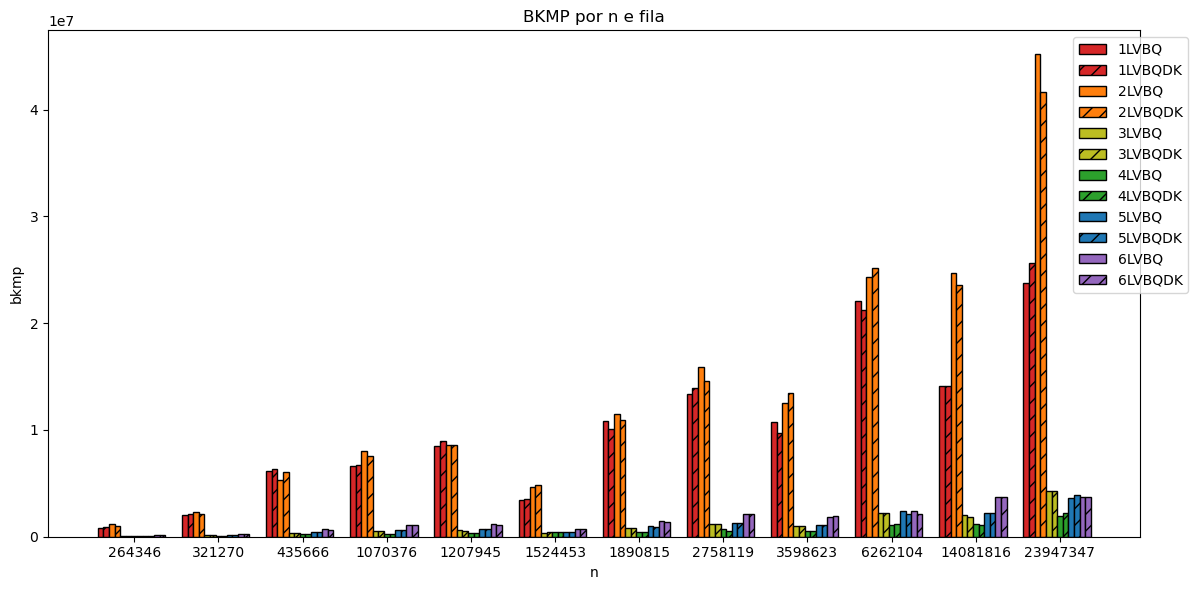

In [152]:
import re
import numpy as np
import matplotlib.pyplot as plt

df = df_vaz.copy()

# --- agregar (caso tenha várias linhas por fila/n) ---
df_agg = df.groupby(["fila", "n"], as_index=False)["bkmp"].mean()

# --- eixos ---
n_vals = sorted(df_agg["n"].unique())
filas = sorted(df_agg["fila"].unique())

x = np.arange(len(n_vals))
width = 0.8 / len(filas)

# --- cores por nível ---
colors = {
    "1": "tab:red",
    "2": "tab:orange",
    "3": "tab:olive",
    "4": "tab:green",
    "5": "tab:blue",
    "6": "tab:purple",
}

plt.figure(figsize=(12, 6))

for i, fila in enumerate(filas):

    df_fila = df_agg[df_agg["fila"] == fila].set_index("n").reindex(n_vals)

    # ===== BINH =====
    if fila == "BINH":
        color = "black"
        hatch = "xx"

    # ===== FIBH =====
    elif fila == "FIBH":
        color = "gold"
        hatch = ".."

    # ===== LVBQ / LVBQDK =====
    else:
        m = re.match(r"\d+", fila)
        nivel = m.group() if m else None

        color = colors.get(nivel, "tab:gray")
        hatch = "//" if "DK" in fila else None

    plt.bar(
        x + i * width,
        df_fila["bkmp"].values,
        width,
        label=fila,
        color=color,
        hatch=hatch,
        edgecolor="black"
    )

# --- ajustes ---
plt.xticks(x + width * len(filas) / 2, n_vals)
plt.xlabel("n")
plt.ylabel("bkmp")
plt.title("BKMP por n e fila")

plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()